In [1]:
# Import all necessary libraries 
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sb

In [2]:
sb.set_theme(style="whitegrid", palette="Set2")
plt.rcParams.update({
    'axes.titlesize': 16,
    'axes.labelsize': 14,
    'xtick.labelsize': 12,
    'ytick.labelsize': 12,
    'legend.fontsize': 12,
    'figure.figsize': (8, 4),
    'axes.titleweight': 'bold',
    'axes.labelweight': 'bold',
})

In [3]:
#Load Dataset
df = pd.read_excel('HousePrediction.xlsx')

In [4]:
# check Number of columns and rows
df.shape


(2919, 13)

In [5]:
# Check column names
df.columns

Index(['Id', 'MSSubClass', 'MSZoning', 'LotArea', 'LotConfig', 'BldgType',
       'OverallCond', 'YearBuilt', 'YearRemodAdd', 'Exterior1st', 'BsmtFinSF2',
       'TotalBsmtSF', 'SalePrice'],
      dtype='object')

In [6]:
# check information about dataframe
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 2919 entries, 0 to 2918
Data columns (total 13 columns):
 #   Column        Non-Null Count  Dtype  
---  ------        --------------  -----  
 0   Id            2919 non-null   int64  
 1   MSSubClass    2919 non-null   int64  
 2   MSZoning      2915 non-null   object 
 3   LotArea       2919 non-null   int64  
 4   LotConfig     2919 non-null   object 
 5   BldgType      2919 non-null   object 
 6   OverallCond   2919 non-null   int64  
 7   YearBuilt     2919 non-null   int64  
 8   YearRemodAdd  2919 non-null   int64  
 9   Exterior1st   2918 non-null   object 
 10  BsmtFinSF2    2918 non-null   float64
 11  TotalBsmtSF   2918 non-null   float64
 12  SalePrice     1460 non-null   float64
dtypes: float64(3), int64(6), object(4)
memory usage: 296.6+ KB


In [7]:
# Check statistical information of dataset
df.describe()

,Id,MSSubClass,LotArea,OverallCond,YearBuilt,YearRemodAdd,BsmtFinSF2,TotalBsmtSF,SalePrice
count,2919.000000,2919.000000,2919.000000,2919.000000,2919.000000,2919.000000,2918.000000,2918.000000,1460.000000
mean,1459.000000,57.137718,10168.114080,5.564577,1971.312778,1984.264474,49.582248,1051.777587,180921.195890
std,842.787043,42.517628,7886.996359,1.113131,30.291442,20.894344,169.205611,440.766258,79442.502883
min,0.000000,20.000000,1300.000000,1.000000,1872.000000,1950.000000,0.000000,0.000000,34900.000000
25%,729.500000,20.000000,7478.000000,5.000000,1953.500000,1965.000000,0.000000,793.000000,129975.000000
50%,1459.000000,50.000000,9453.000000,5.000000,1973.000000,1993.000000,0.000000,989.500000,163000.000000
75%,2188.500000,70.000000,11570.000000,6.000000,2001.000000,2004.000000,0.000000,1302.000000,214000.000000
max,2918.000000,190.000000,215245.000000,9.000000,2010.000000,2010.000000,1526.000000,6110.000000,755000.000000


In [8]:
#Check First rows data 
df.head()


,Id,MSSubClass,MSZoning,LotArea,LotConfig,BldgType,OverallCond,YearBuilt,YearRemodAdd,Exterior1st,BsmtFinSF2,TotalBsmtSF,SalePrice
0,0,60,RL,8450,Inside,1Fam,5,2003,2003,VinylSd,0.0,856.0,208500.0
1,1,20,RL,9600,FR2,1Fam,8,1976,1976,MetalSd,0.0,1262.0,181500.0
2,2,60,RL,11250,Inside,1Fam,5,2001,2002,VinylSd,0.0,920.0,223500.0
3,3,70,RL,9550,Corner,1Fam,5,1915,1970,Wd Sdng,0.0,756.0,140000.0
4,4,60,RL,14260,FR2,1Fam,5,2000,2000,VinylSd,0.0,1145.0,250000.0


In [9]:
#Check Last rows data 

df.tail()

,Id,MSSubClass,MSZoning,LotArea,LotConfig,BldgType,OverallCond,YearBuilt,YearRemodAdd,Exterior1st,BsmtFinSF2,TotalBsmtSF,SalePrice
2914,2914,160,RM,1936,Inside,Twnhs,7,1970,1970,CemntBd,0.0,546.0,NaN
2915,2915,160,RM,1894,Inside,TwnhsE,5,1970,1970,CemntBd,0.0,546.0,NaN
2916,2916,20,RL,20000,Inside,1Fam,7,1960,1996,VinylSd,0.0,1224.0,NaN
2917,2917,85,RL,10441,Inside,1Fam,5,1992,1992,HdBoard,0.0,912.0,NaN
2918,2918,60,RL,9627,Inside,1Fam,5,1993,1994,HdBoard,0.0,996.0,NaN


In [10]:
# Check null values in target variable 

df['SalePrice'].isnull().sum()

1459

In [11]:
# Drop null values 

df = df.dropna(subset=['SalePrice'])

In [12]:
# Check null values in target variable 

df['SalePrice'].isnull().sum()

0

In [13]:
#check missing values in numerical columns
Numerical_features_Count = df.select_dtypes(include= ['number']).shape[1]
print(f'Numerical_features_Count: {Numerical_features_Count}')


Numerical_features_Count: 9


In [14]:
Categorical_feature_Count = df.select_dtypes(include=["object"]).shape[1]
print(f'Categorical_feature_Count: {Categorical_feature_Count}')


Categorical_feature_Count: 4


In [15]:
df.select_dtypes(include= ['number']).head(5)

,Id,MSSubClass,LotArea,OverallCond,YearBuilt,YearRemodAdd,BsmtFinSF2,TotalBsmtSF,SalePrice
0,0,60,8450,5,2003,2003,0.0,856.0,208500.0
1,1,20,9600,8,1976,1976,0.0,1262.0,181500.0
2,2,60,11250,5,2001,2002,0.0,920.0,223500.0
3,3,70,9550,5,1915,1970,0.0,756.0,140000.0
4,4,60,14260,5,2000,2000,0.0,1145.0,250000.0


In [16]:
df.select_dtypes(include= ['object']).head(5)

,MSZoning,LotConfig,BldgType,Exterior1st
0,RL,Inside,1Fam,VinylSd
1,RL,FR2,1Fam,MetalSd
2,RL,Inside,1Fam,VinylSd
3,RL,Corner,1Fam,Wd Sdng
4,RL,FR2,1Fam,VinylSd


In [17]:
df.isnull().sum()

Id              0
MSSubClass      0
MSZoning        0
LotArea         0
LotConfig       0
BldgType        0
OverallCond     0
YearBuilt       0
YearRemodAdd    0
Exterior1st     0
BsmtFinSF2      0
TotalBsmtSF     0
SalePrice       0
dtype: int64

In [18]:
# Year feature 
year_features = ['YearBuilt', 'YearRemodAdd']  

In [19]:
Continuous_Features = ['LotArea' ,'BsmtFinSF2','TotalBsmtSF']

### Categorical Feature Handling

In [21]:
Cat_features = ['MSZoning','LotConfig','BldgType','Exterior1st','MSSubClass']

In [22]:
#Encoded Categorical feature 

for col in Cat_features:
    print(f"\n{col}")
    print(df.groupby(col)['SalePrice'].mean().sort_values(ascending=False))


MSZoning
MSZoning
FV         214014.061538
RL         191004.994787
RH         131558.375000
RM         126316.830275
C (all)     74528.000000
Name: SalePrice, dtype: float64

LotConfig
LotConfig
CulDSac    223854.617021
FR3        208475.000000
Corner     181623.425856
FR2        177934.574468
Inside     176938.047529
Name: SalePrice, dtype: float64

BldgType
BldgType
1Fam      185763.807377
TwnhsE    181959.342105
Twnhs     135911.627907
Duplex    133541.076923
2fmCon    128432.258065
Name: SalePrice, dtype: float64

Exterior1st
Exterior1st
ImStucc    262000.000000
Stone      258500.000000
CemntBd    231690.655738
VinylSd    213732.900971
BrkFace    194573.000000
Plywood    175942.379630
HdBoard    163077.450450
Stucco     162990.000000
WdShing    150655.076923
Wd Sdng    149841.645631
MetalSd    149422.177273
AsbShng    107385.550000
CBlock     105000.000000
AsphShn    100000.000000
BrkComm     71000.000000
Name: SalePrice, dtype: float64

MSSubClass
MSSubClass
60     239948.501672

In [23]:
import warnings
warnings.filterwarnings('ignore', category= FutureWarning)

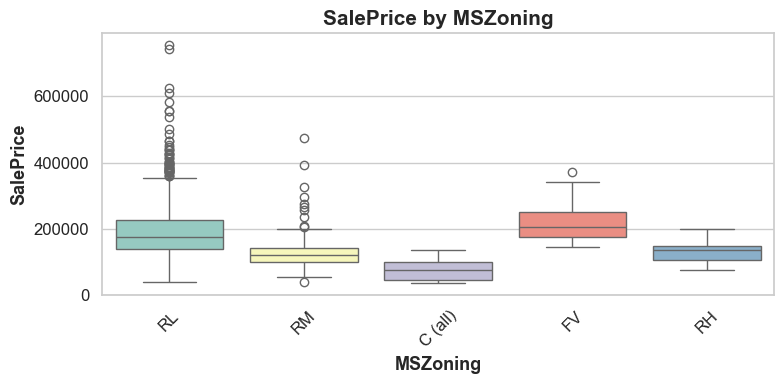

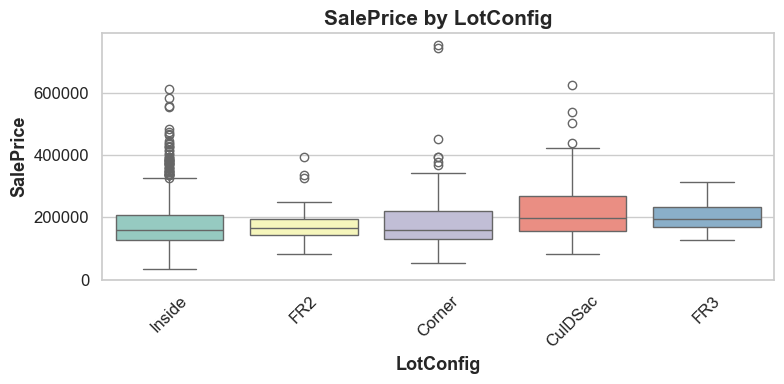

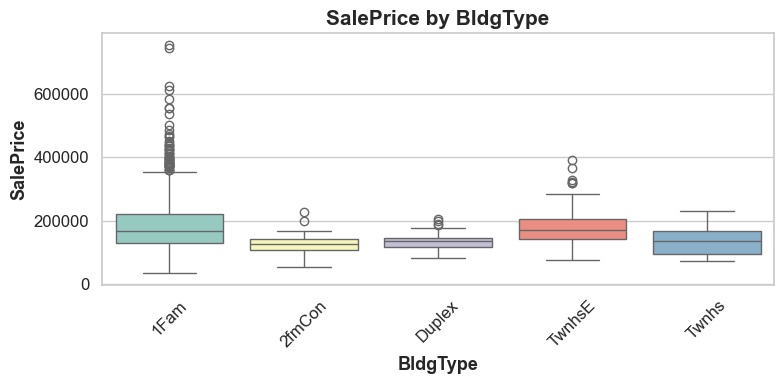

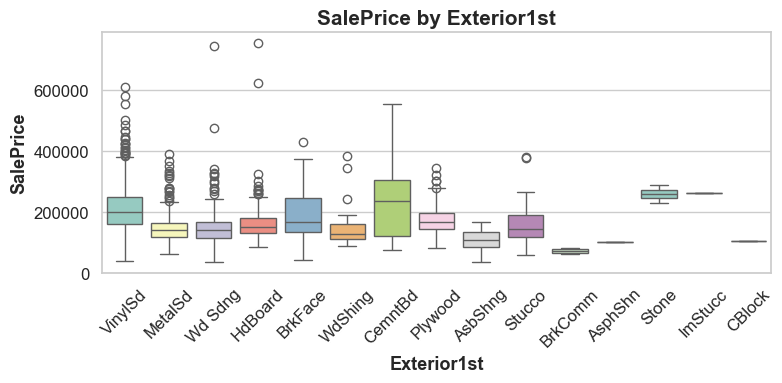

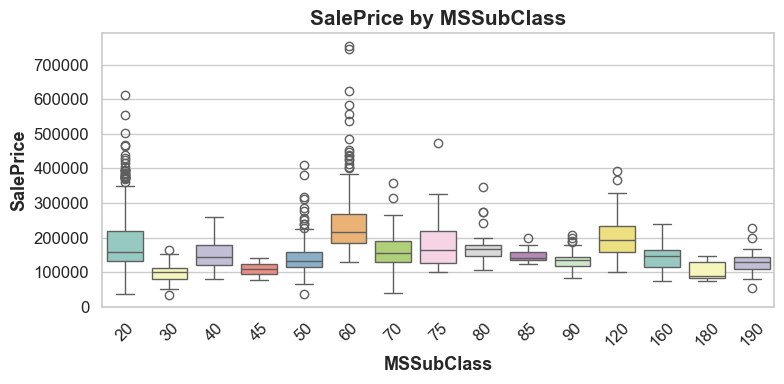

In [24]:
for col in Cat_features:
    plt.figure(figsize=(8,4))
    sb.boxplot(x=col, y='SalePrice', data=df, palette="Set3")
    plt.xticks(rotation=45)
    plt.title(f'SalePrice by {col}', fontsize=15, fontweight='bold')
    plt.xlabel(col, fontsize=13)
    plt.ylabel('SalePrice', fontsize=13)
    plt.tight_layout()
    plt.show()


### Exploratory Data Analysis (EDA)

In [26]:
#correlation check between year feature and sales price 

for col in year_features:
    correlation = df[col].corr(df['SalePrice'])
    print(f'Correlation between: {col}, Sales Price : {correlation:.4f} ')



Correlation between: YearBuilt, Sales Price : 0.5229 
Correlation between: YearRemodAdd, Sales Price : 0.5071 


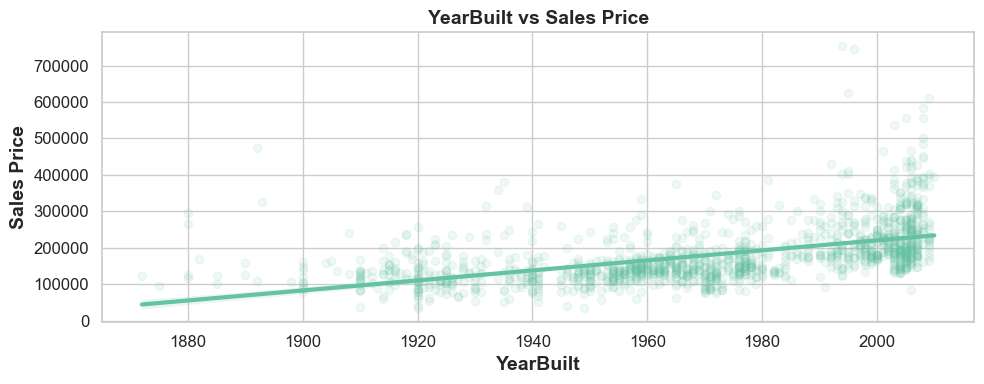

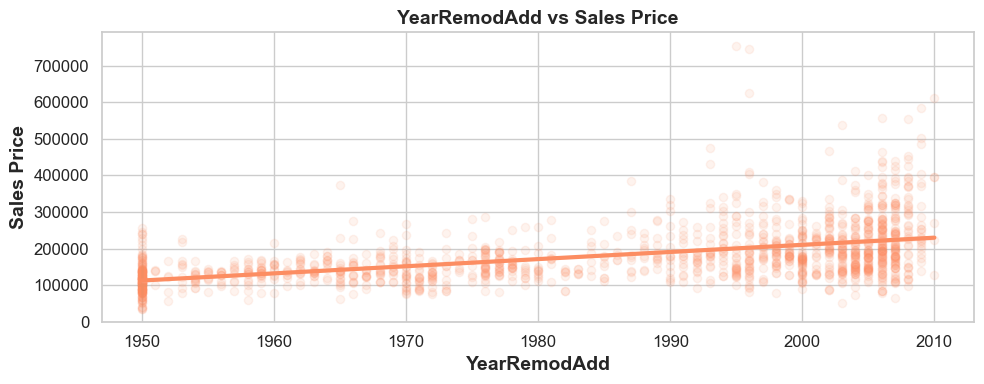

In [27]:
palette = sb.color_palette("Set2")

for i, col in enumerate (year_features):
    plt.figure(figsize= (10,4))
    sb.regplot(
        x= df[col] , 
        y= df['SalePrice'] , 
        scatter_kws= {
            'alpha':0.1,
            's': 35,
            'color': palette[i % len(palette)]},
        line_kws={
            'color': palette[i % len(palette)],
            'linewidth': 3
        }
    )
    
    plt.title(f'{col} vs Sales Price' ,fontsize=14, weight='bold')
    plt.xlabel(col)
    plt.ylabel('Sales Price')
    plt.tight_layout()
    plt.show()

In [29]:
#correlation between Discrete feature and sales price 

df['OverallCond'].corr(df['SalePrice'], method= 'spearman')

-0.12932494660061317

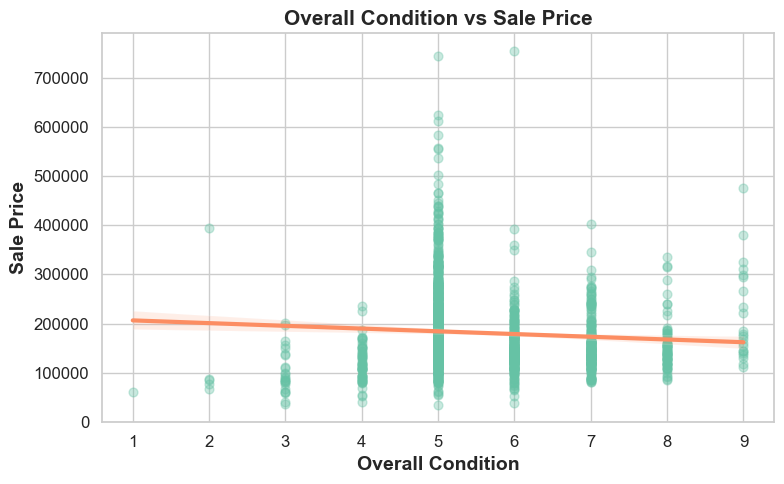

In [30]:

palette = sb.color_palette("Set2")

plt.figure(figsize=(8, 5))
sb.regplot(
    x=df['OverallCond'],
    y=df['SalePrice'],
    scatter_kws={
        'color': palette[0],
        'alpha': 0.35,
        's': 40
    },
    line_kws={
        'color': palette[1],
        'linewidth': 3
    }
)
plt.title('Overall Condition vs Sale Price', fontsize=15, weight='bold')
plt.xlabel('Overall Condition')
plt.ylabel('Sale Price')
plt.tight_layout()
plt.show()


In [31]:
#correlation between Continuous feature and sales price 

for col in Continuous_Features:
    correlation = df[col].corr(df['SalePrice'])
    print(f'Correlation between: {col}, Sales Price : {correlation:.4f} ')


Correlation between: LotArea, Sales Price : 0.2638 
Correlation between: BsmtFinSF2, Sales Price : -0.0114 
Correlation between: TotalBsmtSF, Sales Price : 0.6136 


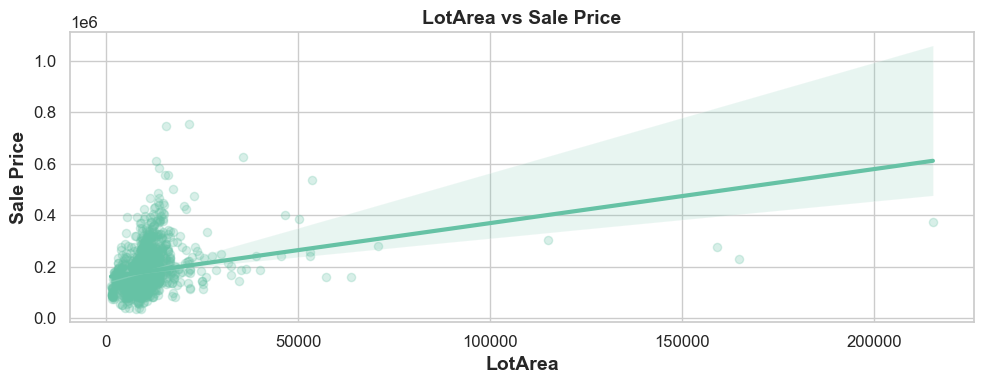

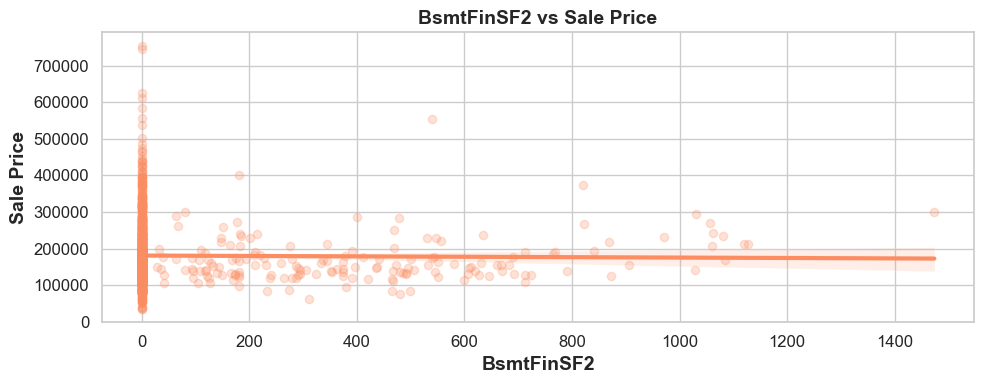

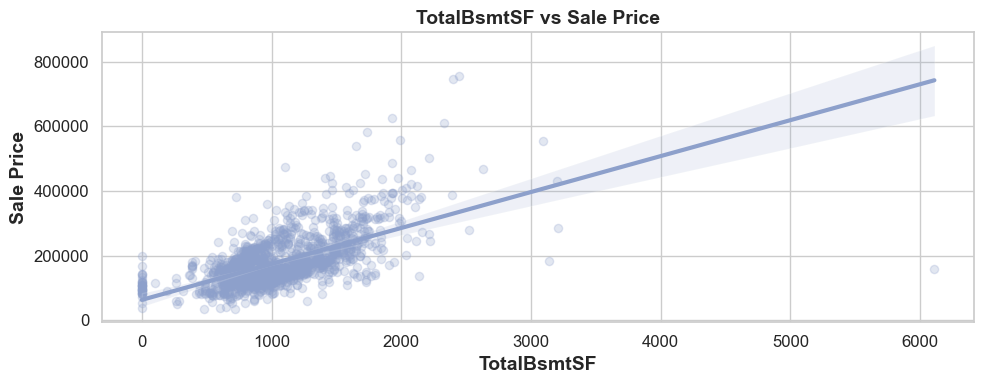

In [32]:
palette = sb.color_palette("Set2")

for i, col in enumerate(Continuous_Features):
    plt.figure(figsize=(10, 4))
    
    sb.regplot(
        x=df[col],
        y=df['SalePrice'],
        scatter_kws={
            'alpha': 0.25,
            's': 35,
            'color': palette[i % len(palette)]
        },
        line_kws={
            'color': palette[i % len(palette)],
            'linewidth': 3
        }
    )
    
    plt.title(f'{col} vs Sale Price', fontsize=14, weight='bold')
    plt.xlabel(col)
    plt.ylabel('Sale Price')
    plt.tight_layout()
    plt.show()


In [33]:
bins = int(np.sqrt(len(df)))
print(bins)

38


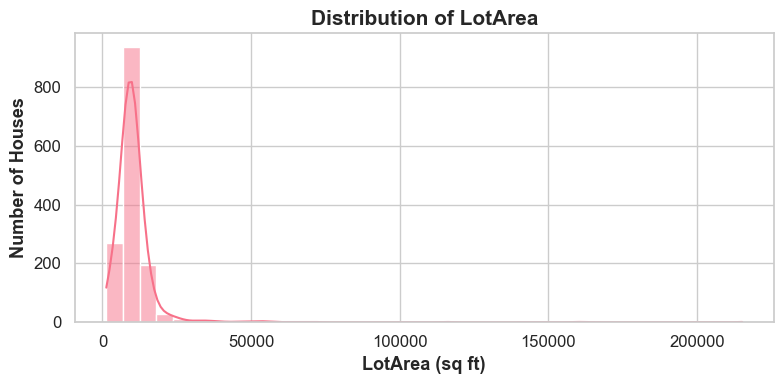

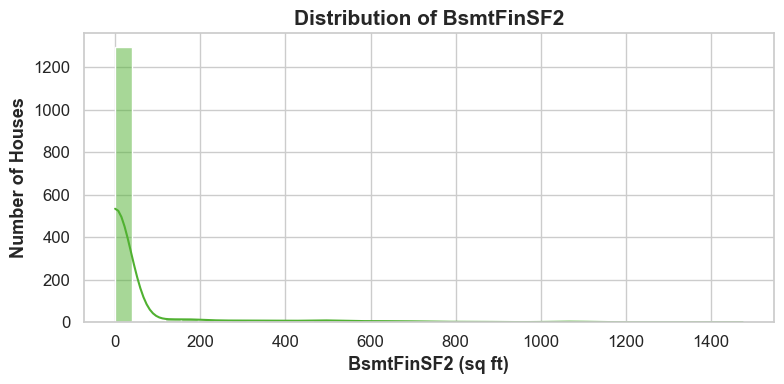

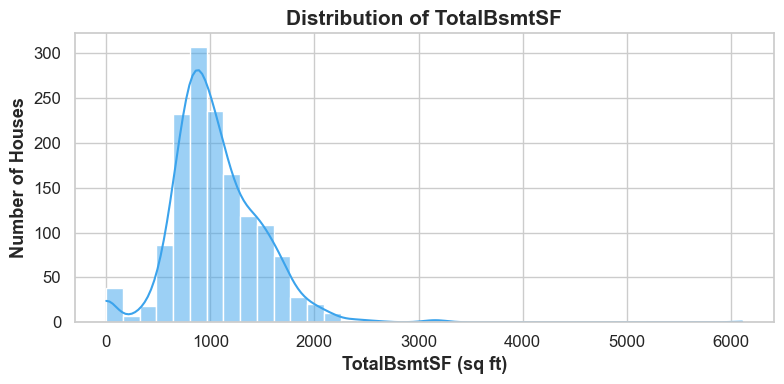

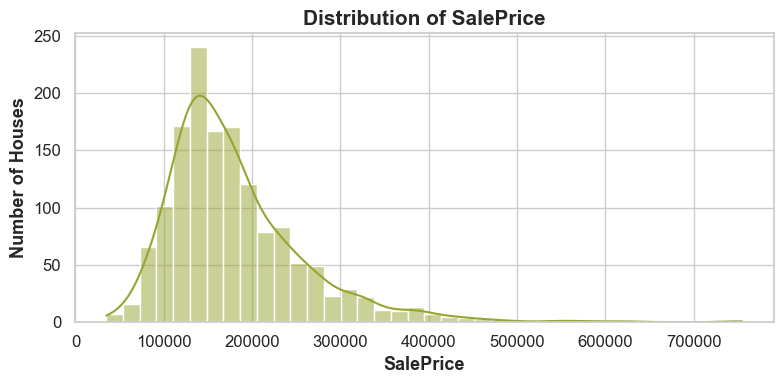

In [34]:
# Analyse the Continous values by creating the histogram to understand the distribution.

for i, col in enumerate(Continuous_Features):
    plt.figure(figsize=(8,4))
    sb.histplot(df[col], bins=38, kde=True, color=sb.color_palette("husl", len(Continuous_Features))[i])
    plt.title(f'Distribution of {col}', fontsize=15, fontweight='bold')
    plt.xlabel(f'{col} (sq ft)', fontsize=13)
    plt.ylabel('Number of Houses', fontsize=13)
    plt.tight_layout()
    plt.show()

# SalePrice distribution with a vibrant color
plt.figure(figsize=(8,4))
sb.histplot(df['SalePrice'], bins=38, kde=True, color=sb.color_palette("husl", 8)[2])
plt.title('Distribution of SalePrice', fontsize=15, fontweight='bold')
plt.xlabel('SalePrice', fontsize=13)
plt.ylabel('Number of Houses', fontsize=13)
plt.tight_layout()
plt.show()


In [35]:
df = df.drop('BsmtFinSF2', axis= 1)

In [36]:
df

,Id,MSSubClass,MSZoning,LotArea,LotConfig,BldgType,OverallCond,YearBuilt,YearRemodAdd,Exterior1st,TotalBsmtSF,SalePrice
0,0,60,RL,8450,Inside,1Fam,5,2003,2003,VinylSd,856.0,208500.0
1,1,20,RL,9600,FR2,1Fam,8,1976,1976,MetalSd,1262.0,181500.0
2,2,60,RL,11250,Inside,1Fam,5,2001,2002,VinylSd,920.0,223500.0
3,3,70,RL,9550,Corner,1Fam,5,1915,1970,Wd Sdng,756.0,140000.0
4,4,60,RL,14260,FR2,1Fam,5,2000,2000,VinylSd,1145.0,250000.0
...,...,...,...,...,...,...,...,...,...,...,...,...
1455,1455,60,RL,7917,Inside,1Fam,5,1999,2000,VinylSd,953.0,175000.0
1456,1456,20,RL,13175,Inside,1Fam,6,1978,1988,Plywood,1542.0,210000.0
1457,1457,70,RL,9042,Inside,1Fam,9,1941,2006,CemntBd,1152.0,266500.0
1458,1458,20,RL,9717,Inside,1Fam,6,1950,1996,MetalSd,1078.0,142125.0


### Feature Engineering

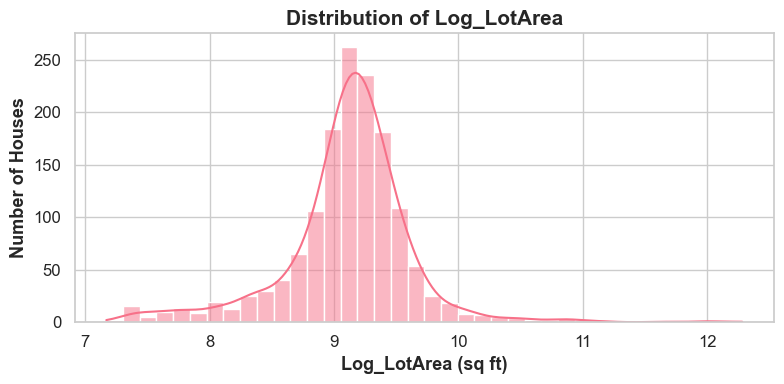

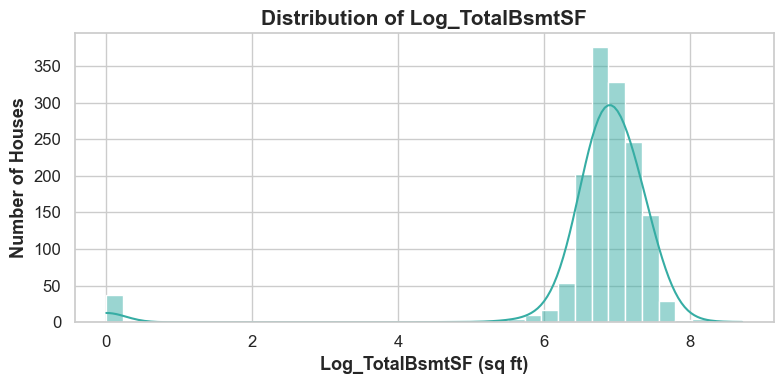

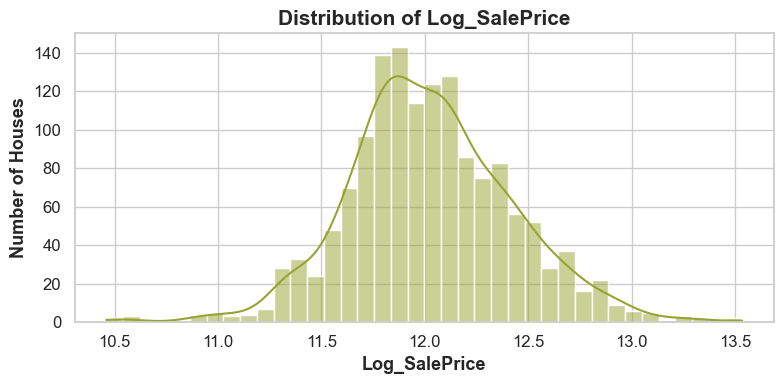

In [38]:
# Apply the Lograthmic Transformation on right skewed variable 

df['Log_LotArea'] = np.log1p(df['LotArea'])
df['Log_TotalBsmtSF'] = np.log1p(df['TotalBsmtSF'])
df['Log_SalePrice'] = np.log1p(df['SalePrice'])

Log_Continuous_Features = ['Log_LotArea', 'Log_TotalBsmtSF']
for i, col in enumerate(Log_Continuous_Features):
    plt.figure(figsize=(8,4))
    sb.histplot(df[col], bins=38, kde=True, color=sb.color_palette("husl", len(Log_Continuous_Features))[i])
    plt.title(f'Distribution of {col}', fontsize=15, fontweight='bold')
    plt.xlabel(f'{col} (sq ft)', fontsize=13)
    plt.ylabel('Number of Houses', fontsize=13)
    plt.tight_layout()
    plt.show()

# SalePrice distribution with a vibrant color
plt.figure(figsize=(8,4))
sb.histplot(df['Log_SalePrice'], bins=38, kde=True, color=sb.color_palette("husl", 8)[2])
plt.title('Distribution of Log_SalePrice', fontsize=15, fontweight='bold')
plt.xlabel('Log_SalePrice', fontsize=13)
plt.ylabel('Number of Houses', fontsize=13)
plt.tight_layout()
plt.show()

In [39]:
df['HasBsmt'] = (df['TotalBsmtSF'] > 0).astype(int)


In [40]:
df['YearBuilt'].describe()


count    1460.000000
mean     1971.267808
std        30.202904
min      1872.000000
25%      1954.000000
50%      1973.000000
75%      2000.000000
max      2010.000000
Name: YearBuilt, dtype: float64

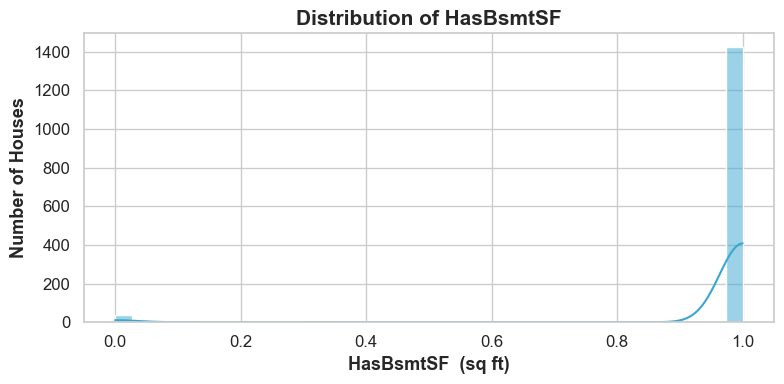

In [41]:

plt.figure(figsize=(8,4))
sb.histplot(df['HasBsmt'], bins=38, kde=True, color=sb.color_palette("husl", 8)[5])
plt.title('Distribution of HasBsmtSF', fontsize=15, fontweight='bold')
plt.xlabel('HasBsmtSF  (sq ft)', fontsize=13)
plt.ylabel('Number of Houses', fontsize=13)
plt.tight_layout()
plt.show()

In [42]:
#calculate House and Renovation Age 

df['YrSold'] = df['YearBuilt'].max()
df['HouseAge'] = df['YrSold'] - df['YearBuilt']
df['RenovationAge'] = df['YrSold'] - df['YearRemodAdd']
df[['YrSold','HouseAge','RenovationAge']]

,YrSold,HouseAge,RenovationAge
0,2010,7,7
1,2010,34,34
2,2010,9,8
3,2010,95,40
4,2010,10,10
...,...,...,...
1455,2010,11,10
1456,2010,32,22
1457,2010,69,4
1458,2010,60,14


In [43]:
df['RecentlyRenovated'] = (df['RenovationAge'] <= 10).astype(int)


### Feature Validation & Cleanup

In [45]:
#drop year built and Year Renovation to avois Multicollinearity

df.drop(['YearBuilt','YearRemodAdd', 'YrSold'], axis= 1, inplace=True)

In [46]:
df.columns


Index(['Id', 'MSSubClass', 'MSZoning', 'LotArea', 'LotConfig', 'BldgType',
       'OverallCond', 'Exterior1st', 'TotalBsmtSF', 'SalePrice', 'Log_LotArea',
       'Log_TotalBsmtSF', 'Log_SalePrice', 'HasBsmt', 'HouseAge',
       'RenovationAge', 'RecentlyRenovated'],
      dtype='object')

In [47]:
df.describe()

,Id,MSSubClass,LotArea,OverallCond,TotalBsmtSF,SalePrice,Log_LotArea,Log_TotalBsmtSF,Log_SalePrice,HasBsmt,HouseAge,RenovationAge,RecentlyRenovated
count,1460.000000,1460.000000,1460.000000,1460.000000,1460.000000,1460.000000,1460.000000,1460.000000,1460.000000,1460.000000,1460.000000,1460.000000,1460.000000
mean,729.500000,56.897260,10516.828082,5.575342,1057.429452,180921.195890,9.110966,6.750560,12.024057,0.974658,38.732192,25.134247,0.378082
std,421.610009,42.300571,9981.264932,1.112799,438.705324,79442.502883,0.517369,1.145712,0.399449,0.157217,30.202904,20.645407,0.485074
min,0.000000,20.000000,1300.000000,1.000000,0.000000,34900.000000,7.170888,0.000000,10.460271,0.000000,0.000000,0.000000,0.000000
25%,364.750000,20.000000,7553.500000,5.000000,795.750000,129975.000000,8.929898,6.680541,11.775105,1.000000,10.000000,6.000000,0.000000
50%,729.500000,50.000000,9478.500000,5.000000,991.500000,163000.000000,9.156887,6.900227,12.001512,1.000000,37.000000,16.000000,0.000000
75%,1094.250000,70.000000,11601.500000,6.000000,1298.250000,214000.000000,9.358976,7.169542,12.273736,1.000000,56.000000,43.000000,1.000000
max,1459.000000,190.000000,215245.000000,9.000000,6110.000000,755000.000000,12.279537,8.717846,13.534474,1.000000,138.000000,60.000000,1.000000


In [48]:
# check correlation between features to detect redundancy and multicollinearity, not to measure importance.
df[['HasBsmt','HouseAge', 'RenovationAge', 'RecentlyRenovated' ,'Log_TotalBsmtSF']].corr()

,HasBsmt,HouseAge,RenovationAge,RecentlyRenovated,Log_TotalBsmtSF
HasBsmt,1.000000,-0.078510,-0.137053,0.062814,0.950411
HouseAge,-0.078510,1.000000,0.592855,-0.449639,-0.199087
RenovationAge,-0.137053,0.592855,1.000000,-0.748609,-0.205200
RecentlyRenovated,0.062814,-0.449639,-0.748609,1.000000,0.122312
Log_TotalBsmtSF,0.950411,-0.199087,-0.205200,0.122312,1.000000


In [49]:
# Feature engineering is where multicollinearity is introduced

final_features = [
    'Log_LotArea',
    'Log_TotalBsmtSF',
    'HasBsmt',
    'HouseAge',
    'RenovationAge',
    'RecentlyRenovated'
]

df[final_features + ['Log_SalePrice']] \
    .corr()['Log_SalePrice'] \
    .sort_values(ascending=False)

Log_SalePrice        1.000000
Log_LotArea          0.399923
RecentlyRenovated    0.393178
Log_TotalBsmtSF      0.372838
HasBsmt              0.199634
RenovationAge       -0.565608
HouseAge            -0.586570
Name: Log_SalePrice, dtype: float64

### Handle the Categorical Variables

In [51]:
#Encoded Categories by One Hot Coding (categorical to numerical)

df['MSSubClass'] = df['MSSubClass'].astype(str)

In [52]:
df['MSSubClass']

0       60
1       20
2       60
3       70
4       60
        ..
1455    60
1456    20
1457    70
1458    20
1459    20
Name: MSSubClass, Length: 1460, dtype: object

In [53]:
df = df.drop(['Id','LotArea', 'HasBsmt','TotalBsmtSF'], axis= 1)

In [54]:
cat_cols = ['MSZoning', 'LotConfig', 'BldgType', 'Exterior1st', 'MSSubClass']


In [55]:
df_encoded = pd.get_dummies(
    df,
    columns=cat_cols,
    drop_first=True, dtype= int
)

In [56]:
df_encoded.shape


(1460, 48)

In [57]:
df_encoded.columns


Index(['OverallCond', 'SalePrice', 'Log_LotArea', 'Log_TotalBsmtSF',
       'Log_SalePrice', 'HouseAge', 'RenovationAge', 'RecentlyRenovated',
       'MSZoning_FV', 'MSZoning_RH', 'MSZoning_RL', 'MSZoning_RM',
       'LotConfig_CulDSac', 'LotConfig_FR2', 'LotConfig_FR3',
       'LotConfig_Inside', 'BldgType_2fmCon', 'BldgType_Duplex',
       'BldgType_Twnhs', 'BldgType_TwnhsE', 'Exterior1st_AsphShn',
       'Exterior1st_BrkComm', 'Exterior1st_BrkFace', 'Exterior1st_CBlock',
       'Exterior1st_CemntBd', 'Exterior1st_HdBoard', 'Exterior1st_ImStucc',
       'Exterior1st_MetalSd', 'Exterior1st_Plywood', 'Exterior1st_Stone',
       'Exterior1st_Stucco', 'Exterior1st_VinylSd', 'Exterior1st_Wd Sdng',
       'Exterior1st_WdShing', 'MSSubClass_160', 'MSSubClass_180',
       'MSSubClass_190', 'MSSubClass_20', 'MSSubClass_30', 'MSSubClass_40',
       'MSSubClass_45', 'MSSubClass_50', 'MSSubClass_60', 'MSSubClass_70',
       'MSSubClass_75', 'MSSubClass_80', 'MSSubClass_85', 'MSSubClass_90'],
   

In [58]:
df_encoded.head()

,OverallCond,SalePrice,Log_LotArea,Log_TotalBsmtSF,Log_SalePrice,HouseAge,RenovationAge,RecentlyRenovated,MSZoning_FV,MSZoning_RH,...,MSSubClass_30,MSSubClass_40,MSSubClass_45,MSSubClass_50,MSSubClass_60,MSSubClass_70,MSSubClass_75,MSSubClass_80,MSSubClass_85,MSSubClass_90
0,5,208500.0,9.042040,6.753438,12.247699,7,7,1,0,0,...,0,0,0,0,1,0,0,0,0,0
1,8,181500.0,9.169623,7.141245,12.109016,34,34,0,0,0,...,0,0,0,0,0,0,0,0,0,0
2,5,223500.0,9.328212,6.825460,12.317171,9,8,1,0,0,...,0,0,0,0,1,0,0,0,0,0
3,5,140000.0,9.164401,6.629363,11.849405,95,40,0,0,0,...,0,0,0,0,0,1,0,0,0,0
4,5,250000.0,9.565284,7.044033,12.429220,10,10,1,0,0,...,0,0,0,0,1,0,0,0,0,0


## Model Building:-

In [60]:
from sklearn.model_selection import train_test_split

X = df_encoded.drop(['SalePrice', 'Log_SalePrice'], axis=1)
y = df_encoded['Log_SalePrice']

X_train, X_test, Y_train, Y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)



In [61]:
#Feature Scaling
from sklearn.preprocessing import StandardScaler

Scale = StandardScaler()

X_train_scaled = Scale.fit_transform(X_train)
X_test_scaled = Scale.transform(X_test)

In [62]:
#Train Linear Regression
from sklearn.linear_model import LinearRegression

Model = LinearRegression()
Model.fit(X_train_scaled, Y_train)

LinearRegression()

In [63]:
#  Predict on Test Data
Y_pred_log = Model.predict(X_test_scaled)

In [64]:
Y_pred_Price = np.expm1(Y_pred_log)
Y_test_Price = np.expm1(Y_test)

In [65]:
# Evaluate Model
from sklearn.metrics import mean_squared_error, r2_score
rmse = (np.sqrt(mean_squared_error(Y_test, Y_pred_log)))
r2 = r2_score(Y_test, Y_pred_log)              

print('RMSE (log)', rmse)
print('R2', r2)

#R² ~ 0.70–0.80 → very good linear model
#Lower RMSE → better prediction accuracy

RMSE (log) 0.2403202712634827
R2 0.6905121546333814


️# Interpret Coefficients


In [67]:
coef_df = pd.DataFrame({
    'Feature': X.columns,
    'Coefficient': Model.coef_
}).sort_values(by='Coefficient', ascending=False)

coef_df.head(10)

,Feature,Coefficient
1,Log_LotArea,0.137050
8,MSZoning_RL,0.103646
9,MSZoning_RM,0.082060
2,Log_TotalBsmtSF,0.070037
6,MSZoning_FV,0.055433
41,MSSubClass_70,0.053364
20,Exterior1st_BrkFace,0.049449
42,MSSubClass_75,0.044042
0,OverallCond,0.044036
7,MSZoning_RH,0.032451


In [68]:
coef_df.tail(10)


,Feature,Coefficient
11,LotConfig_FR2,-0.012502
43,MSSubClass_80,-0.014300
23,Exterior1st_HdBoard,-0.015129
14,BldgType_2fmCon,-0.015563
44,MSSubClass_85,-0.017698
33,MSSubClass_180,-0.022646
36,MSSubClass_30,-0.037115
35,MSSubClass_20,-0.043537
4,RenovationAge,-0.073943
3,HouseAge,-0.213855


In [69]:
# Ridge linear regression check for more stability in model and reduce multicollinearity

from sklearn.linear_model import Ridge

Ridge = Ridge(alpha = 1.0)
Ridge.fit(X_train_scaled, Y_train)

y_ridge_pred = Ridge.predict(X_test_scaled)

rmse_ridge = mean_squared_error(y_ridge_pred, Y_test)
r2_score_ridge = r2_score(y_ridge_pred, Y_test)

print(rmse_ridge)
print(r2_score_ridge)

0.05810778404545871
0.42809459767868185


In [70]:
comparison_df = pd.DataFrame({
    'Model': ['Linear Regression', 'Ridge Regression'],
    'RMSE (log)': [rmse, rmse_ridge],
    'R2 Score': [r2, r2_score_ridge]
})

comparison_df

,Model,RMSE (log),R2 Score
0,Linear Regression,0.240320,0.690512
1,Ridge Regression,0.058108,0.428095


Your trained model expects input in exactly the same format as the training data X.

That means:

Same number of columns

Same column names

Same order

2D structure (rows × columns)

In [72]:
# model test on new house data

new_house = pd.DataFrame(0, index=[0], columns=X.columns)


In [73]:
new_house['Log_LotArea'] = np.log1p(8000)
new_house['Log_TotalBsmtSF'] = np.log1p(900)
new_house['HouseAge'] = 20
new_house['RenovationAge'] = 5
new_house['MSZoning_RL'] = 1


In [74]:
new_house_scaled = Scale.transform(new_house)


In [75]:
log_price_pred = Model.predict(new_house_scaled)


In [76]:
price_pred = np.expm1(log_price_pred)
print(f"Predicted House Price: ₹{price_pred[0]:,.0f}")


Predicted House Price: ₹160,038
